# 🌱 Irrigation Prediction (XGBoost + CatBoost + Stacking)

### Strategy:
1. **Model Diversity:**
   - **XGBoost:** Learns via histogram splits. We feed it Target Encoded high-cardinality interactions.
   - **CatBoost:** Uses symmetric trees and ordered target statistics. We feed it the raw categorical strings natively. Utilizing `devices='0:1'` to run on both T4 GPUs.
3. **Original Data Exploitation:** Target means from the original dataset are injected as numeric features.
4. **Smart Stacking Blending:** Instead of a simple average, we train a `LogisticRegression` meta-model on the OOF (Out-of-Fold) probabilities of both models.
5. **Threshold Optimization:** We apply `scipy.optimize` to the meta-model's predictions to find the exact probability boundaries that maximize Balanced Accuracy.

## 1. Imports & Configuration

In [1]:
# ===================================================================
# 1. Imports & Configuration
# ===================================================================
import numpy as np
import pandas as pd
import xgboost as xgb
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import TargetEncoder
from sklearn.linear_model import LogisticRegression
from scipy.optimize import minimize
from itertools import combinations
import warnings
import gc

warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter('ignore')

# Configuration
N_SPLITS = 5
RANDOM_STATE = 42
TARGET = 'Irrigation_Need'

TARGET_MAP = {'Low': 0, 'Medium': 1, 'High': 2}
TARGET_INV_MAP = {0: 'Low', 1: 'Medium', 2: 'High'}

## 2. Load Data

In [2]:
# ===================================================================
# 2. Load Data
# ===================================================================
path_synthetic = '/kaggle/input/competitions/playground-series-s6e4'
path_original = '/kaggle/input/datasets/miadul/irrigation-water-requirement-prediction-dataset/irrigation_prediction.csv'

train = pd.read_csv(path_synthetic + '/train.csv')
test = pd.read_csv(path_synthetic + '/test.csv')
subm = pd.read_csv(path_synthetic + '/sample_submission.csv')

try:
    orig = pd.read_csv(path_original)
    if 'id' in orig.columns:
        orig = orig.drop(columns=['id'])
    print(f"Original dataset loaded with shape: {orig.shape}")
except FileNotFoundError:
    print("⚠️ Original dataset not found. Proceeding with synthetic data only.")
    orig = pd.DataFrame() 

print(f"Synthetic Train shape: {train.shape}")
print(f"Synthetic Test shape:  {test.shape}")

Original dataset loaded with shape: (10000, 20)
Synthetic Train shape: (630000, 21)
Synthetic Test shape:  (270000, 20)


## 3. Preprocessing & Original Data TE

In [3]:
# ===================================================================
# 3. Preprocessing & Original Data TE
# ===================================================================
train[TARGET] = train[TARGET].map(TARGET_MAP)
if not orig.empty and TARGET in orig.columns:
    orig[TARGET] = orig[TARGET].map(TARGET_MAP)

features = [col for col in test.columns if col != 'id']
base_cat_features = test.select_dtypes(include=['object']).columns.tolist()

# Extract Target Encodings from the Original Data
if not orig.empty:
    print(f"Extracting Original Data Target Encodings...")
    for c in features:
        tmp = orig.groupby(c)[TARGET].mean().astype('float32')
        tmp.name = f"TE_ORIG_{c}"
        
        train = train.merge(tmp, on=c, how='left')
        test = test.merge(tmp, on=c, how='left')
        orig = orig.merge(tmp, on=c, how='left')
        
        train[tmp.name] = train[tmp.name].fillna(0.5)
        test[tmp.name] = test[tmp.name].fillna(0.5)
        orig[tmp.name] = orig[tmp.name].fillna(0.5)

Extracting Original Data Target Encodings...


## 4. Generate 2-Way Interactions

In [4]:
# ===================================================================
# 4. Generate 2-Way Interactions
# ===================================================================
TE_columns = []
print("Generating 2-way combinations...")

for cols in combinations(features, 2):
    name = f"{cols[0]}-{cols[1]}"
    
    train[name] = train[cols[0]].astype(str) + '_' + train[cols[1]].astype(str)
    test[name] = test[cols[0]].astype(str) + '_' + test[cols[1]].astype(str)
    if not orig.empty:
        orig[name] = orig[cols[0]].astype(str) + '_' + orig[cols[1]].astype(str)
    
    combined = pd.concat([train[name], test[name]] + ([orig[name]] if not orig.empty else []), ignore_index=True)
    combined, _ = combined.factorize()
    
    if pd.Series(combined).nunique() > len(combined) // 2:
        train = train.drop(name, axis=1)
        test = test.drop(name, axis=1)
        if not orig.empty:
            orig = orig.drop(name, axis=1)
        continue
        
    TE_columns.append(name)

final_features = [c for c in train.columns if c != TARGET and c != 'id']

# Separate predictors
X_train_synth = train[final_features].copy()
y_train_synth = train[TARGET].copy()
X_test = test[final_features].copy()

if not orig.empty:
    X_orig = orig[final_features].copy()
    y_orig = orig[TARGET].copy()

# List of all categorical features (Base + Interactions)
all_cat_features = base_cat_features + TE_columns

# Ensure categorical columns are strings for CatBoost, and category dtype for XGBoost
for df in [X_train_synth, X_test] + ([X_orig] if not orig.empty else []):
    for col in all_cat_features:
        df[col] = df[col].astype(str) 

# Get indices of categorical features for CatBoost
cb_cat_features_idx = [X_train_synth.columns.get_loc(c) for c in all_cat_features]

Generating 2-way combinations...


## 5. Model Definitions & Custom Metrics

In [5]:
# ===================================================================
# 5. Model Definitions & Custom Metrics
# ===================================================================
def balanced_accuracy():
    def xgb_balanced_accuracy(y_true, y_pred):
        y_pred_labels = np.argmax(y_pred.reshape(-1, 3), axis=1)
        return balanced_accuracy_score(y_true.astype(int), y_pred_labels)
    xgb_balanced_accuracy.__name__ = 'bal_ACC'
    return xgb_balanced_accuracy

xgb_params = {
    'objective': 'multi:softprob', 
    'num_class': 3,
    'tree_method': 'hist',
    'enable_categorical': True,
    'learning_rate': 0.01,
    'max_depth': 6,
    'n_estimators': 15000,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'max_bin': 1024,
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
    'device': 'cuda' 
}

cb_params = {
    'iterations': 15000,
    'learning_rate': 0.02,
    'depth': 6,
    'loss_function': 'MultiClass',
    'eval_metric': 'MultiClass',
    'auto_class_weights': 'Balanced',
    'task_type': 'GPU',
    'devices': '0:1', # Uses BOTH T4 GPUs
    'random_seed': RANDOM_STATE,
    'early_stopping_rounds': 500,
    'verbose': 250
}

## 6. Out-Of-Fold Training (Level 1)

In [6]:
# ===================================================================
# 6. Out-Of-Fold Training (Level 1)
# ===================================================================
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# Matrices to store Level 1 probabilities
xgb_oof = np.zeros((len(X_train_synth), 3)) 
cb_oof = np.zeros((len(X_train_synth), 3)) 
xgb_test = np.zeros((len(X_test), 3)) 
cb_test = np.zeros((len(X_test), 3)) 

print("🚀 Starting Level 1 Training (XGBoost + CatBoost)...\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_synth, y_train_synth)):
    print(f"--- FOLD {fold+1} ---")
    
    # 1. Base Splits
    X_tr, y_tr = X_train_synth.iloc[train_idx].copy(), y_train_synth.iloc[train_idx].copy()
    X_va, y_va = X_train_synth.iloc[val_idx].copy(), y_train_synth.iloc[val_idx].copy()
    X_te = X_test.copy()
    
    if not orig.empty:
        X_tr = pd.concat([X_tr, X_orig], axis=0).reset_index(drop=True)
        y_tr = pd.concat([y_tr, y_orig], axis=0).reset_index(drop=True)
        
    # -----------------------------------------------------
    # Train CatBoost (Uses raw strings)
    # -----------------------------------------------------
    print("Training CatBoost...")
    train_pool = Pool(X_tr, y_tr, cat_features=cb_cat_features_idx)
    val_pool = Pool(X_va, y_va, cat_features=cb_cat_features_idx)
    test_pool = Pool(X_te, cat_features=cb_cat_features_idx)
    
    cb_model = CatBoostClassifier(**cb_params)
    cb_model.fit(train_pool, eval_set=val_pool)
    
    cb_oof[val_idx] = cb_model.predict_proba(val_pool)
    cb_test += cb_model.predict_proba(test_pool) / N_SPLITS
    
    del cb_model, train_pool, val_pool, test_pool
    gc.collect()

    # -----------------------------------------------------
    # Train XGBoost (Requires Target Encoding)
    # -----------------------------------------------------
    print("Training XGBoost...")
    encoder = TargetEncoder(target_type='multiclass', cv=5, random_state=RANDOM_STATE)
    
    # Target Encode categorical columns for XGBoost
    te_tr = pd.DataFrame(encoder.fit_transform(X_tr[all_cat_features], y_tr))
    te_tr.columns = encoder.get_feature_names_out(all_cat_features)
    X_tr_xgb = pd.concat([X_tr.reset_index(drop=True).drop(columns=all_cat_features), te_tr], axis=1)
    
    te_va = pd.DataFrame(encoder.transform(X_va[all_cat_features]))
    te_va.columns = encoder.get_feature_names_out(all_cat_features)
    X_va_xgb = pd.concat([X_va.reset_index(drop=True).drop(columns=all_cat_features), te_va], axis=1)
    
    te_te = pd.DataFrame(encoder.transform(X_te[all_cat_features]))
    te_te.columns = encoder.get_feature_names_out(all_cat_features)
    X_te_xgb = pd.concat([X_te.reset_index(drop=True).drop(columns=all_cat_features), te_te], axis=1)
    
    # Convert remaining pandas objects to category for XGBoost if any slipped through
    for df in [X_tr_xgb, X_va_xgb, X_te_xgb]:
        for col in df.select_dtypes(include=['object']).columns:
            df[col] = df[col].astype('category')

    weights = compute_sample_weight(class_weight='balanced', y=y_tr)
    
    xgb_model = xgb.XGBClassifier(**xgb_params, eval_metric=balanced_accuracy(),
                                  callbacks=[xgb.callback.EarlyStopping(rounds=500, metric_name='bal_ACC', maximize=True, save_best=True)])
    xgb_model.fit(X_tr_xgb, y_tr, sample_weight=weights, eval_set=[(X_va_xgb, y_va)], verbose=250)
    
    xgb_oof[val_idx] = xgb_model.predict_proba(X_va_xgb)
    xgb_test += xgb_model.predict_proba(X_te_xgb) / N_SPLITS
    
    del xgb_model, X_tr, y_tr, X_va, y_va, X_te, X_tr_xgb, X_va_xgb, X_te_xgb
    gc.collect()

🚀 Starting Level 1 Training (XGBoost + CatBoost)...

--- FOLD 1 ---
Training CatBoost...
0:	learn: 1.0642171	test: 1.0638096	best: 1.0638096 (0)	total: 158ms	remaining: 39m 23s
250:	learn: 0.1081194	test: 0.1070310	best: 0.1070310 (250)	total: 6.06s	remaining: 5m 56s
500:	learn: 0.0963310	test: 0.0970506	best: 0.0970506 (500)	total: 10.7s	remaining: 5m 9s
750:	learn: 0.0914172	test: 0.0934133	best: 0.0934133 (750)	total: 15.1s	remaining: 4m 46s
1000:	learn: 0.0880658	test: 0.0913773	best: 0.0913773 (1000)	total: 19.9s	remaining: 4m 37s
1250:	learn: 0.0852539	test: 0.0899450	best: 0.0899450 (1250)	total: 24.7s	remaining: 4m 31s
1500:	learn: 0.0830090	test: 0.0888103	best: 0.0888103 (1500)	total: 29.6s	remaining: 4m 25s
1750:	learn: 0.0808973	test: 0.0879828	best: 0.0879828 (1750)	total: 34.4s	remaining: 4m 20s
2000:	learn: 0.0790276	test: 0.0873158	best: 0.0873123 (1995)	total: 39s	remaining: 4m 13s
2250:	learn: 0.0773105	test: 0.0867111	best: 0.0867111 (2250)	total: 43.3s	remaining: 4m

### Level 2: Smart Stacking & Threshold Optimization
We now take the 3 probabilities from XGBoost and the 3 probabilities from CatBoost (6 features total) and train a Meta-Model to figure out the best way to combine them. Finally, we optimize the decision thresholds.

In [7]:
# ===================================================================
# 7. Level 2 Stacking
# ===================================================================
print("\n🧠 Training Level 2 Stacker...")

# Concatenate OOFs to create meta-training data (shape: N, 6)
meta_X_train = np.hstack([xgb_oof, cb_oof])
meta_X_test = np.hstack([xgb_test, cb_test])

# Train Logistic Regression on the OOF probabilities
meta_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
meta_model.fit(meta_X_train, y_train_synth)

# Predict final stacked probabilities
stack_oof_probs = meta_model.predict_proba(meta_X_train)
stack_test_probs = meta_model.predict_proba(meta_X_test)

stack_oof_preds = np.argmax(stack_oof_probs, axis=1)
baseline_stack_score = balanced_accuracy_score(y_train_synth, stack_oof_preds)
print(f"Baseline Stacked OOF Balanced Accuracy: {baseline_stack_score:.5f}")

# ===================================================================
# 8. Threshold Optimization
# ===================================================================
print("\n⚙️ Optimizing Thresholds...")

def optimize_thresholds(weights):
    weighted_oof = stack_oof_probs * weights
    pred_classes = np.argmax(weighted_oof, axis=1)
    return -balanced_accuracy_score(y_train_synth, pred_classes)

initial_weights = [1.0, 1.0, 1.0]
res = minimize(optimize_thresholds, initial_weights, method='Nelder-Mead')

best_weights = res.x
optimized_oof_classes = np.argmax(stack_oof_probs * best_weights, axis=1)
optimized_score = balanced_accuracy_score(y_train_synth, optimized_oof_classes)

print(f"Optimized Class Multipliers: {best_weights}")
print(f"Final Optimized OOF Balanced Accuracy: {optimized_score:.5f}")


🧠 Training Level 2 Stacker...
Baseline Stacked OOF Balanced Accuracy: 0.97801

⚙️ Optimizing Thresholds...
Optimized Class Multipliers: [1.19920877 0.62165853 1.2867939 ]
Final Optimized OOF Balanced Accuracy: 0.97864


## 7. Final Inference & Submission

In [8]:
# ===================================================================
# 9. Final Inference & Submission
# ===================================================================
# Apply the discovered optimal weights to our stacked test probabilities
final_weighted_test_probs = stack_test_probs * best_weights
final_test_classes = np.argmax(final_weighted_test_probs, axis=1)

# Map integers back to class strings
subm[TARGET] = final_test_classes
subm[TARGET] = subm[TARGET].map(TARGET_INV_MAP)

# Save submission
subm.to_csv('submission.csv', index=False)
print("🏆 Submission saved successfully!")
subm.head()

🏆 Submission saved successfully!


,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low


### Visualizing Ensemble Diagnostics & Performance
To understand our final stacked model's behavior, we will visualize three key aspects of our Out-of-Fold (OOF) predictions:

1. **Final Confusion Matrix:** Shows exactly which classes the optimized meta-model is confusing.
2. **Class Distribution:** Compares the raw counts of our true labels against our final optimized predictions.
3. **Base Model Correlation:** A heatmap showing how correlated the predictions of XGBoost and CatBoost are. If the correlation is slightly lower (e.g., < 0.95), it proves our models are learning different patterns, which is exactly why blending them improves the score!

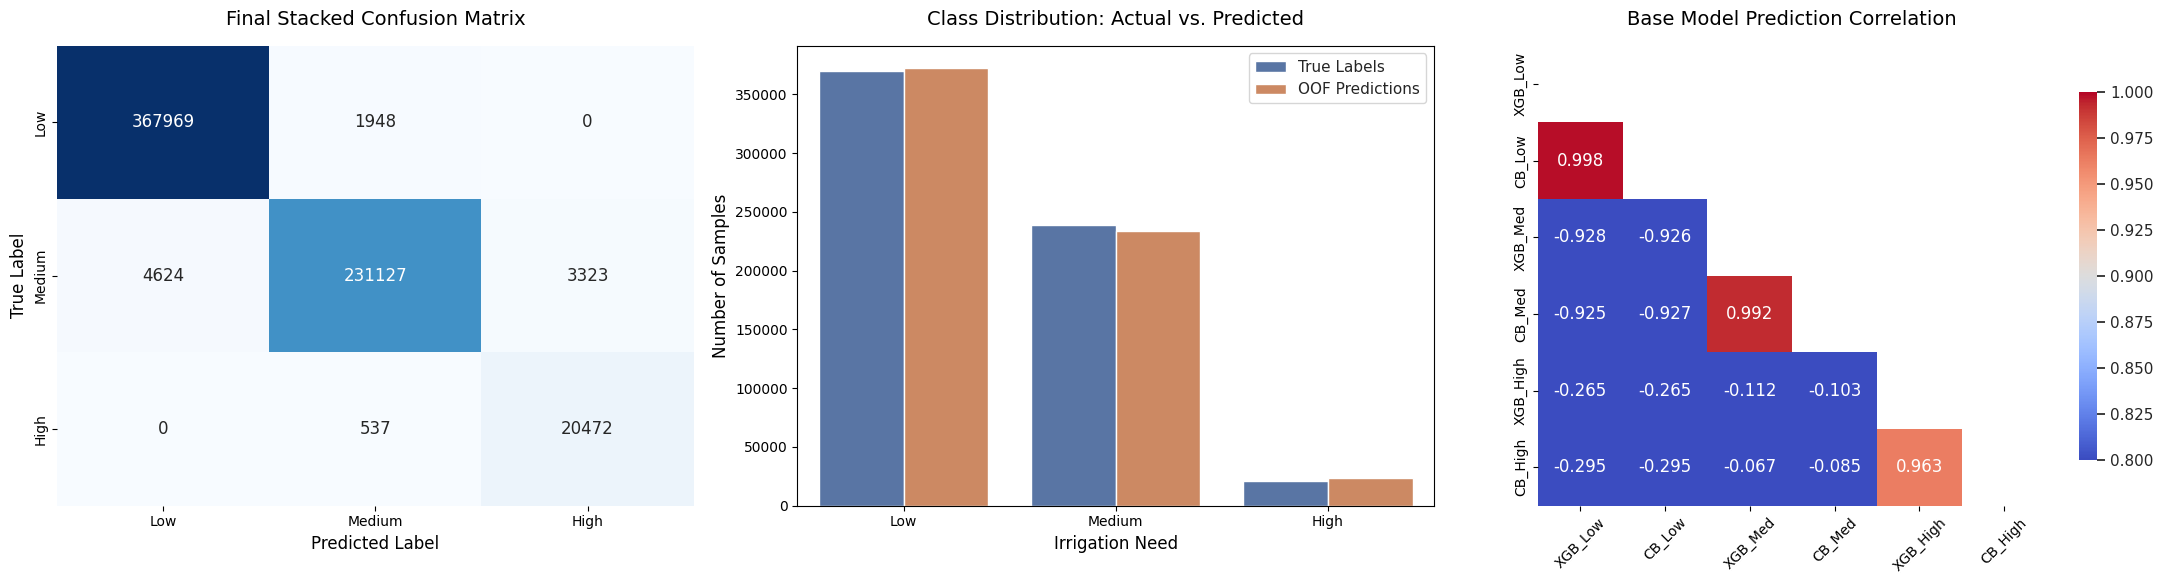

In [9]:
# ===================================================================
# 10. Ensemble Diagnostics & Visualization
# ===================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Set up the plotting grid
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# Plot 1: Optimized OOF Confusion Matrix
# ---------------------------------------------------------
cm = confusion_matrix(y_train_synth, optimized_oof_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'],
            cbar=False, annot_kws={"size": 12})

axes[0].set_title('Final Stacked Confusion Matrix', fontsize=14, pad=15)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)

# ---------------------------------------------------------
# Plot 2: True vs Predicted Distributions
# ---------------------------------------------------------
dist_df = pd.DataFrame({
    'True Labels': y_train_synth.map(TARGET_INV_MAP),
    'OOF Predictions': pd.Series(optimized_oof_classes).map(TARGET_INV_MAP)
})

dist_melted = dist_df.melt(var_name='Source', value_name='Class')

sns.countplot(data=dist_melted, x='Class', hue='Source', ax=axes[1], 
              palette=['#4C72B0', '#DD8452'], order=['Low', 'Medium', 'High'])

axes[1].set_title('Class Distribution: Actual vs. Predicted', fontsize=14, pad=15)
axes[1].set_xlabel('Irrigation Need', fontsize=12)
axes[1].set_ylabel('Number of Samples', fontsize=12)
axes[1].legend(title='')

# ---------------------------------------------------------
# Plot 3: Base Model Prediction Correlation
# ---------------------------------------------------------
# Create a dataframe of the base model probabilities to check correlation
corr_df = pd.DataFrame({
    'XGB_Low': xgb_oof[:, 0], 'CB_Low': cb_oof[:, 0],
    'XGB_Med': xgb_oof[:, 1], 'CB_Med': cb_oof[:, 1],
    'XGB_High': xgb_oof[:, 2], 'CB_High': cb_oof[:, 2]
})

# Calculate correlation matrix
corr_matrix = corr_df.corr()

# Mask the upper triangle for a cleaner look
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='coolwarm', 
            vmin=0.8, vmax=1.0, ax=axes[2], cbar_kws={"shrink": .8})

axes[2].set_title('Base Model Prediction Correlation', fontsize=14, pad=15)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()